# 11 — D11 `msgarch_regime`: MS-GARCH(1,1)-t (Haas-Mittnik-Paolella 2004), filtro de Hamilton

Familia **F5 (Volatilidad con cambio de régimen)**. Detector **EXPLORATORIO** (Tanda 4).
Univariante sobre el **retorno log del S&P 500** (desde 1985).

## La decisión técnica (honesta)
El estado del arte (CP2) avisó: **no hay librería madura de MS-GARCH en Python**; el
estándar es el paquete `MSGARCH` de **R**, y aquí `rpy2` **no** está instalado (no se
puentea a R) y `arch` 8.0 hace GARCH univariante pero **no** MS-GARCH. En lugar de
declararlo no implementable, se **implementa desde cero** la variante que **sí** es
tratable en Python puro: el **MS-GARCH de Haas-Mittnik-Paolella (2004)**, estimado por
**máxima verosimilitud con un filtro de Hamilton** propio (numpy/scipy, sin R).

## Por qué HMP-2004 sí es tratable (y la "naive" no)
Un MS-GARCH *naive* sufre **path dependence** (la varianza de $t$ depende de la de
$t{-}1$, que depende del régimen de $t{-}1$…) → la verosimilitud integra sobre $2^t$
trayectorias = intratable. **HMP-2004** lo resuelve con $K$ recursiones GARCH **en
paralelo**, una por régimen, alimentada **solo por su propia varianza pasada**:

$$h_{k,t} = \omega_k + \alpha_k\,\varepsilon_{t-1}^2 + \beta_k\,h_{k,t-1},\qquad
  y_t\mid(s_t{=}k)\sim \mu + \sqrt{h_{k,t}}\;t_\nu\;(\mathrm{Var}{=}1)$$

Sin path dependence, la verosimilitud se computa con el **filtro de Hamilton** en
$O(T\,K^2)$. Esa es justo la razón por la que HMP-2004 es el caballo de batalla del
MS-GARCH. **Innovación t** (colas gordas, Bollerslev 1987); $\nu$ compartido y $\mu$
única por **parsimonia / estabilidad** del ML (lo que separa regímenes es la dinámica
de varianza $\omega,\alpha,\beta$).

## Posición frente a D5 y D6 (no es redundante)
- **D5** `markov_switching_var`: régimen de Markov, varianza **constante** dentro del
  régimen (sin ARCH).
- **D6** `garch_t_vol`: dinámica GARCH(1,1)-t pero **un solo** régimen (umbral de sigma).
- **D11** = la **síntesis**: régimen de Markov latente **Y** dinámica GARCH-t dentro de
  cada régimen, con **posterior de crisis FILTRADO** (Hamilton) y logL/AIC/BIC.

## Honestidad del alcance
Es la especificación **paralela / path-INDEPENDIENTE** de HMP. **No** reproduce el
MS-GARCH path-dependiente "completo" (intratable) ni el colapso de **Gray (1996)**, ni
las múltiples familias del paquete `MSGARCH` de R (eGARCH/gjr por régimen, bayesiano…).
Una familia: GARCH(1,1) por régimen, innovación t, $\nu$ compartido.

## Índice navegable

> **Lectura rápida (TL;DR).** D11 es un detector **EXPLORATORIO** y su resultado es
> **NEGATIVO**, y lo documentamos como tal. La pieza central de este notebook es la
> **§7 (degeneración fold-a-fold)**: la evidencia visual de que el MS-GARCH de 10
> parámetros, estimado por ML no convexo en una ventana rolling corta con `n_init=1`,
> **colapsa a un único régimen** en la inmensa mayoría de bloques walk-forward. El
> etiquetado económico por fold de ese único régimen resulta **arbitrario** (a veces
> "crisis", a veces "calma"), lo que produce la patología observada: cobertura de la
> **GFC ≈ 0 %** y, a la vez, **tasa de falsas alarmas ≈ 0.95**. Es un **negativo bien
> capitalizado a favor de la parsimonia**: D8 (HMM-t) y D6 (GARCH-t de un régimen),
> más simples, ganan a este modelo más expresivo pero infra-identificado.

| § | Sección | Qué encontrarás |
|---|---------|-----------------|
| [1](#sec1) | Ajuste in-sample | parámetros (ω,α,β,ν,P) por régimen, verificación de etiquetado |
| [2](#sec2) | Verificación de causalidad | el posterior filtrado del bloque no mira el futuro |
| [3](#sec3) | Walk-forward causal | protocolo rolling 6 años + re-estimación semestral |
| [4](#sec4) | P(crisis) filtrada | timeline del posterior con ventanas de crisis/trampa |
| [5](#sec5) | S&P 500 por régimen | precio coloreado por el régimen CAUSAL OOS |
| [6](#sec6) | Cobertura por ventana | barras de cobertura + timeline de régimen |
| [7](#sec7) | **Degeneración fold-a-fold** | **la figura clave: qué folds colapsan a 1 régimen** |
| [8](#sec8) | Diagnóstico de causa raíz | POR QUÉ degenera: posterior plano + etiquetado en esquinas |
| [9](#sec9) | Tabla fold a fold | resumen tabular sobre las ventanas conocidas |
| [10](#sec10) | Volcado de métricas | fila canónica de 32 columnas a results/ |
| [11](#sec11) | Conclusión | el negativo, capitalizado a favor de la parsimonia |

**Figuras que produce este notebook** (en `results/`): `d11_prob_timeline.png`,
`d11_sp500_regimes.png`, `d11_coverage.png` (existentes) · `d11_fold_degeneration.png`,
`d11_root_cause.png`, `d11_fold_table.png` (**nuevas**, §7–§9).

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz                                # helpers de figura del estilo de casa
viz.use_house_style()                              # rcParams homogéneos (D1..D12 idénticos)
from detectors.msgarch_regime import MSGarchRegime

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
spx_ret = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
X = pd.DataFrame({'SP500_ret': spx_ret}).dropna()
X.index = pd.to_datetime(X.index); X = X.sort_index()
mkt = X['SP500_ret']                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
print('X (histórico largo):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = régimen de vol, no retorno).')

X (histórico largo): (10294, 1) | 1985-01-03 -> 2026-06-12
OBLIGATORIO pasar market_returns a walk_forward Y evaluate (señal = régimen de vol, no retorno).


<a id="sec1"></a>
## 1. Ajuste in-sample: parámetros del MS-GARCH-t por régimen

Ajuste sobre toda la muestra (multistart `n_init=3`) solo para inspeccionar el modelo;
la clasificación comparable es la **causal** de §3. El orden económico (0=calma ·
1=crisis) lo fija `label_states_economically` con el retorno del S&P 500 (núcleo
vol-primario, Arreglo 4): **crisis = régimen de mayor volatilidad**.

In [2]:
det_is = MSGarchRegime(n_init=3, maxiter=300).fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
p = det_is._params
order = det_is._canonical_order                            # [interno_calma, interno_crisis]
lab = {0: 'calma', 1: 'crisis'}
print('MS-GARCH(1,1)-t HMP-2004  (retornos x100), por REGIMEN INTERNO:')
for k in (0, 1):
    canon = int(np.where(order == k)[0][0])
    print(f'  regimen interno {k} -> canonico {canon} ({lab[canon]}): '
          f'omega={p[f"om{k}"]:.4f} alpha={p[f"al{k}"]:.4f} beta={p[f"be{k}"]:.4f} '
          f'(alpha+beta={p[f"al{k}"]+p[f"be{k}"]:.3f})')
print(f'  mu={p["mu"]:.4f}  nu={p["nu"]:.2f} (colas gordas)  '
      f'p00={p["p00"]:.4f}  p11={p["p11"]:.4f}')
A = det_is.transition_canonical()
print('\nTransicion CANONICA P(j|i) [calma,crisis]:')
print(np.round(A, 4))
vol = det_is.uncond_vol_canonical()
print(f'\nVol incondicional CANONICA (x100): calma={vol[0]:.3f}  crisis={vol[1]:.3f}')
print(f'logL={det_is.score(X):.1f} | n_params={det_is.n_parameters()} | '
      f'AIC={det_is.aic(X):.1f} | BIC={det_is.bic(X):.1f}')

# VERIFICACION CRITICA: crisis canonico = ALTA vol (no invertido)
states_is = pd.Series(det_is.predict(X), index=X.index)
std_cri = mkt[states_is == det_is.crisis_state].std()
std_cal = mkt[states_is == 0].std()
print(f'\nVERIFICACION etiquetado: std retorno CRISIS={std_cri:.4f} vs CALMA={std_cal:.4f}')
assert std_cri > std_cal and vol[1] > vol[0], 'INVERTIDO: crisis deberia ser ALTA vol'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA vol. No invertido.')

MS-GARCH(1,1)-t HMP-2004  (retornos x100), por REGIMEN INTERNO:
  regimen interno 0 -> canonico 0 (calma): omega=0.0021 alpha=0.0291 beta=0.9678 (alpha+beta=0.997)
  regimen interno 1 -> canonico 1 (crisis): omega=0.0421 alpha=0.2118 beta=0.7877 (alpha+beta=0.999)
  mu=0.0788  nu=5.29 (colas gordas)  p00=0.9961  p11=0.9946

Transicion CANONICA P(j|i) [calma,crisis]:
[[0.9961 0.0039]
 [0.0054 0.9946]]

Vol incondicional CANONICA (x100): calma=0.818  crisis=9.180
logL=-13365.5 | n_params=10 | AIC=26750.9 | BIC=26823.3

VERIFICACION etiquetado: std retorno CRISIS=0.0147 vs CALMA=0.0090
OK -> crisis (estado canonico 1) = ALTA vol. No invertido.


<a id="sec2"></a>
## 2. Verificación de CAUSALIDAD del posterior filtrado

El filtro de Hamilton es causal nativo (cada $P(s_t\mid y_{\le t})$ usa solo el pasado),
pero el walk-forward no debe reestimar con el test. El posterior del bloque se computa
con **parámetros congelados** y burn-in de train. Test: ocultar el futuro **no** debe
cambiar el posterior filtrado del bloque.

In [3]:
det_c = MSGarchRegime(n_init=1, maxiter=150).fit(X.loc[:'2007-12-31'])
det_c.label_states_economically(X.loc[:'2007-12-31'], market_returns=mkt.loc[:'2007-12-31'])
block = X.loc['2008-01-01':'2008-12-31']
pb = det_c.predict_proba(block)[:, det_c.crisis_state]
pp = pd.Series(det_c.predict_proba(X.loc['2008-01-01':'2010-12-31'])[:, det_c.crisis_state],
               index=X.loc['2008-01-01':'2010-12-31'].index).loc[block.index].values
maxdiff = float(np.abs(pb - pp).max())
print(f'max |P(crisis)_bloque(ver futuro) - P(crisis)_bloque(ocultar futuro)| = {maxdiff:.2e}')
assert maxdiff < 1e-9, 'El posterior filtrado del bloque NO es causal'
print('causal_ok = True -> P(s_t|y<=t) usa solo retornos <= t (burn-in + filtro de Hamilton)')

max |P(crisis)_bloque(ver futuro) - P(crisis)_bloque(ocultar futuro)| = 0.00e+00
causal_ok = True -> P(s_t|y<=t) usa solo retornos <= t (burn-in + filtro de Hamilton)


<a id="sec3"></a>
## 3. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` re-estima el MS-GARCH en ventanas **ROLLING de 6 años** y predice el
bloque de `step=126` días (semestral) con parámetros congelados. Se usa **ROLLING +
step semestral + `n_init=1`** para acotar el coste del ML no convexo (~13 min); dentro
de cada bloque el posterior FILTRADO da resolución **diaria** y causal. Se pasa
**`market_returns=mkt`** para re-fijar el orden económico de estados de forma robusta
(la señal es un régimen de vol, no el retorno).

In [4]:
TRAIN_SIZE = 252 * 6   # ventana rolling de ~6 anios
STEP = 126             # re-estimacion semestral (coste del ML MS-GARCH)
panel = ev.walk_forward(lambda: MSGarchRegime(n_init=1, maxiter=100), X,
                        market_returns=mkt, train_size=TRAIN_SIZE, step=STEP,
                        expanding=False, min_train=TRAIN_SIZE)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(),
      '| n_oos =', len(panel), '| folds =', panel['fold'].nunique())
states_c = panel['state']; p_c = panel['p_crisis']

# Detector ajustado a TODA la muestra solo para logL/AIC/BIC; clasificacion = panel OOS
res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'msgarch_regime'
print('ventana_eval:', res.extra['ventana_eval'])
print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

OOS: 1991-03-04 -> 2026-06-12 | n_oos = 8782 | folds = 70


ventana_eval: 1991-03-04→2026-06-12 (n=8782)

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :   0.0%
  EuroDebt_2011   :  11.8%
  COVID_2020      :  20.0%
  Inflation_2022  :  35.9%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:   0.0%
  Selloff_Q4_2018 :  93.7%

false_alarm_rate = 0.949 | switching = 0.0312 | dur media = 31.9 d | label_stability = 0.889


<a id="sec4"></a>
## 4. P(crisis) filtrada y ventanas de crisis

Posterior filtrado $P(s_t{=}\text{crisis}\mid y_{\le t})$ del walk-forward causal.
Bandas rojas = ventanas de crisis conocidas; naranjas = trampas (2013/2018).

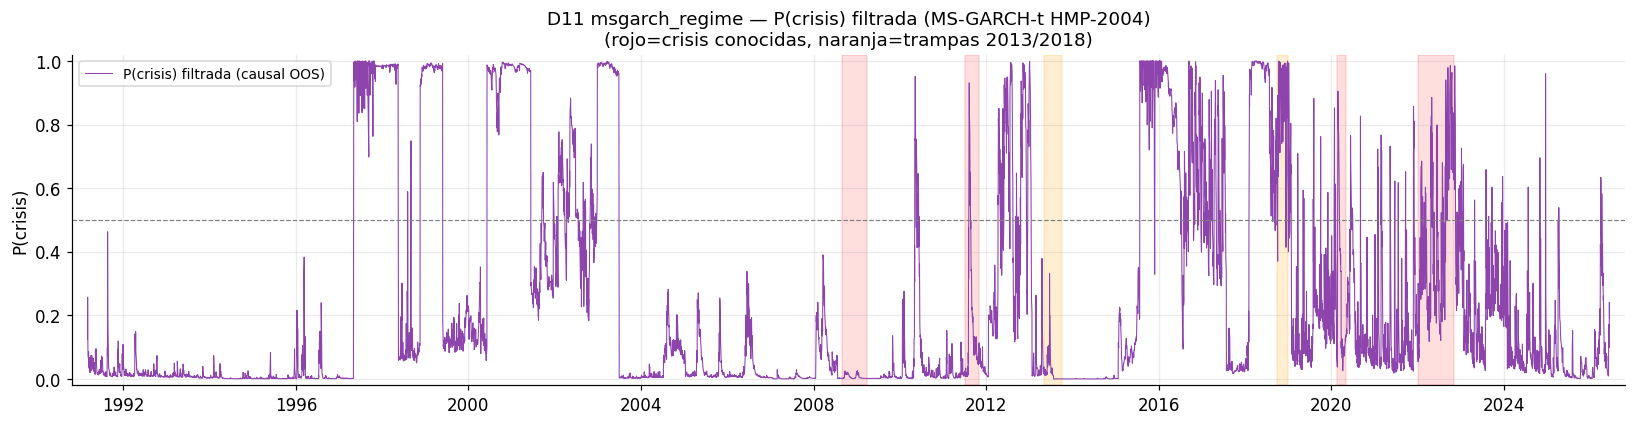

In [5]:
fig, ax = plt.subplots(figsize=(15, 4.0))
ax.plot(p_c.index, p_c.values, color='#8e44ad', lw=0.7, label='P(crisis) filtrada (causal OOS)')
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
for a, b in ev.CRISIS_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax.set_title('D11 msgarch_regime — P(crisis) filtrada (MS-GARCH-t HMP-2004)\n(rojo=crisis conocidas, naranja=trampas 2013/2018)')
ax.set_ylabel('P(crisis)'); ax.legend(loc='upper left', fontsize=9); ax.margins(x=0.01); ax.set_ylim(-0.02, 1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'd11_prob_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec5"></a>
## 5. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal. Líneas =
ventanas de crisis conocidas. Cubre 2008 y 2011 OOS (ventana larga desde 1985).

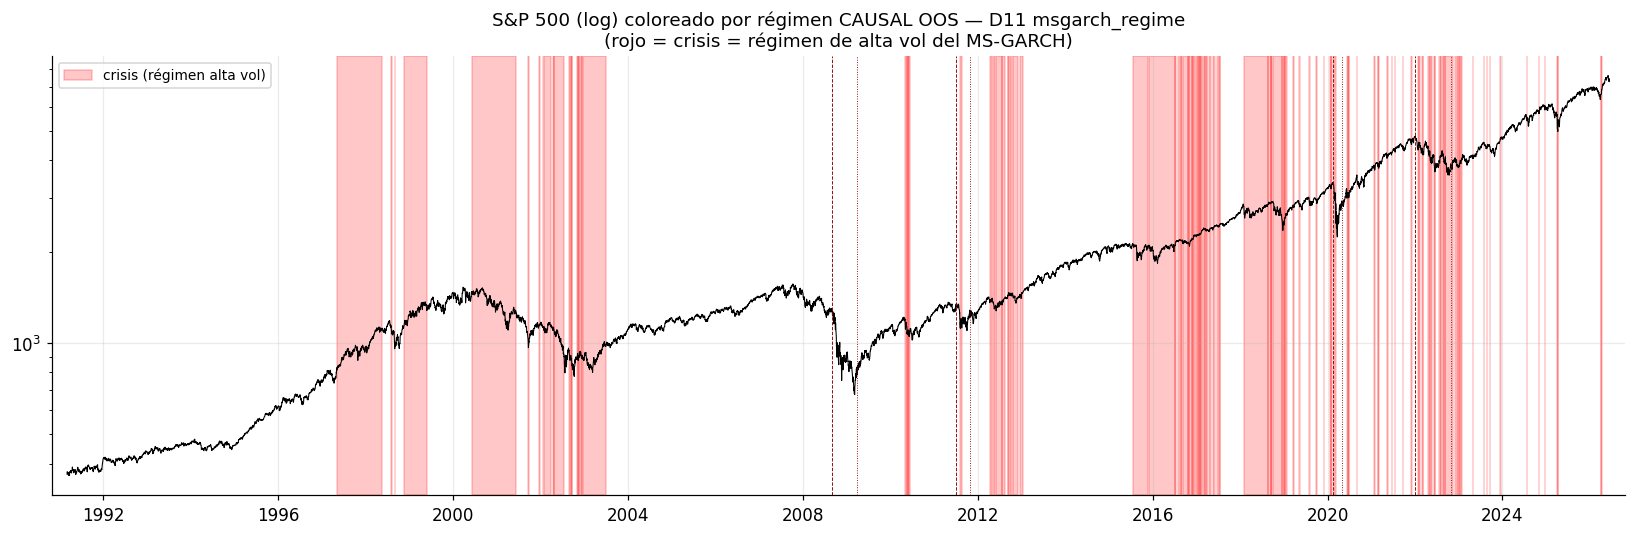

In [6]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por régimen CAUSAL OOS — D11 msgarch_regime\n(rojo = crisis = régimen de alta vol del MS-GARCH)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (régimen alta vol)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd11_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec6"></a>
## 6. Cobertura por ventana y timeline de régimen

Cobertura OOS por ventana de crisis (rojo) y por ventana trampa (naranja), más el
timeline diario de régimen. **Anticipo del resultado negativo:** la cobertura de la
**GFC** se hunde mientras las falsas alarmas se disparan; las §§7–8 descomponen esa
paradoja fold a fold y exhiben su causa.

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,0.0%
EuroDebt_2011,crisis,11.8%
COVID_2020,crisis,20.0%
Inflation_2022,crisis,35.9%
TaperTantrum_2013,trampa,0.0%
Selloff_Q4_2018,trampa,93.7%


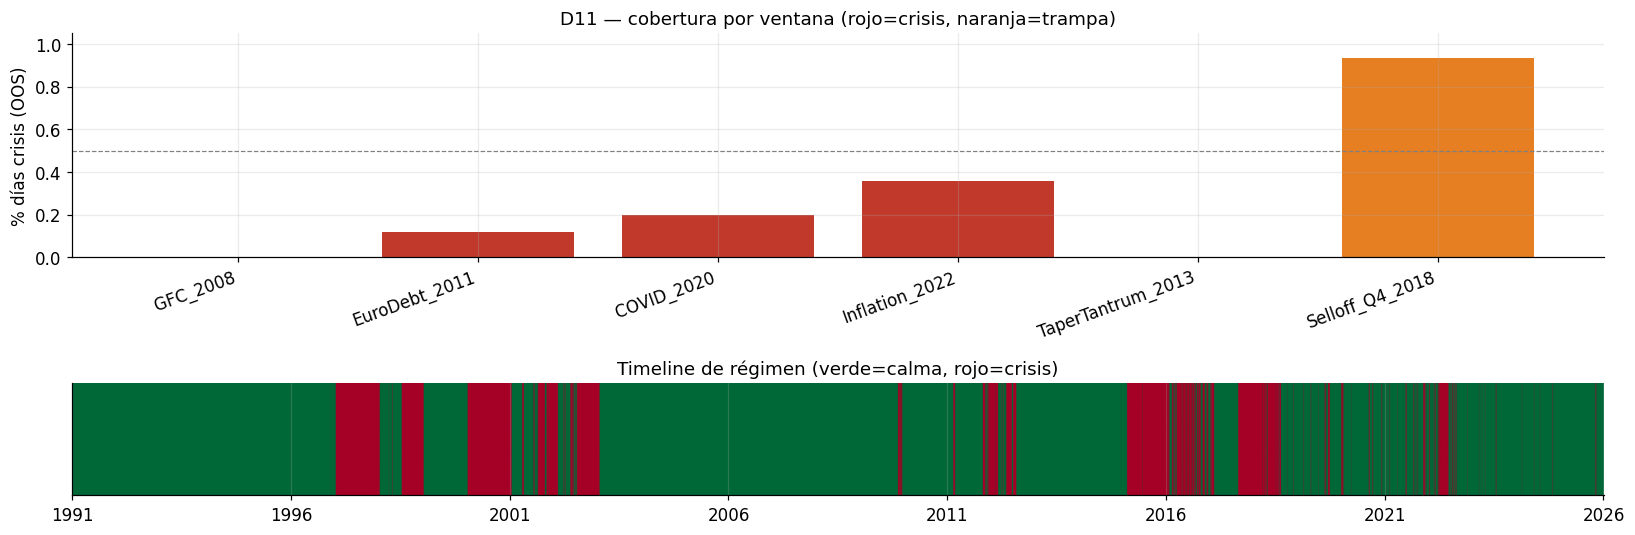

In [7]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmp = pd.DataFrame(rows).set_index('ventana')
display(cmp.style.format({'cobertura_OOS': '{:.1%}'}))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), gridspec_kw={'height_ratios': [2, 1]})
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmp['tipo']]
ax1.bar(cmp.index, cmp['cobertura_OOS'].values, color=colors)
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('% días crisis (OOS)'); ax1.set_ylim(0, 1.05)
ax1.set_title('D11 — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax1.set_xticklabels(cmp.index, rotation=20, ha='right')
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de régimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd11_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec7"></a>
## 7. Anatomía de la DEGENERACIÓN fold-a-fold (la figura clave)

Las métricas agregadas de §6 esconden *cómo* falla el modelo. Aquí lo abrimos en canal:
el panel `panel` del walk-forward ya trae, por fecha, el **fold** (la ventana que la
predijo), el **estado canónico** (0=calma, 1=crisis) y la **P(crisis)** filtrada. De ahí
derivamos, **sin re-estimar nada** (coste cero, solo agregación del panel ya calculado),
tres diagnósticos por fold:

1. **nº de regímenes DISTINTOS predichos** en el bloque. Un MS-GARCH sano debería
   alternar calma/crisis dentro de una ventana de 6 meses que contenga turbulencia;
   si cae a **1**, el modelo ha **colapsado** a un único régimen (no hay cambio de
   régimen que detectar).
2. **fracción de días etiquetados "crisis"** por fold. En un detector útil esta
   fracción es moderada y se concentra en las crisis reales; aquí veremos que se
   **pega a 0 o a 1**, señal de un etiquetado económico **arbitrario** del único
   régimen superviviente.
3. cruce con las **ventanas de crisis conocidas** (sombra roja tenue): así se ve si el
   colapso ocurre **incluso durante la GFC**.

> **Cómo leerla.** Barras rojas arriba = folds colapsados a 1 régimen. Barras rojas
> abajo = folds con etiquetado degenerado (≈0 o ≈1). Si casi todas las barras de arriba
> son rojas, el modelo prácticamente **nunca** identifica dos regímenes out-of-sample:
> esa es la degeneración, hecha imagen.

folds totales = 70 | colapsados a 1 régimen = 42 (60%) | con etiquetado en esquina (<=5% o >=95%) = 53
folds que solapan crisis CONOCIDAS = 8; de ellos colapsados = 3


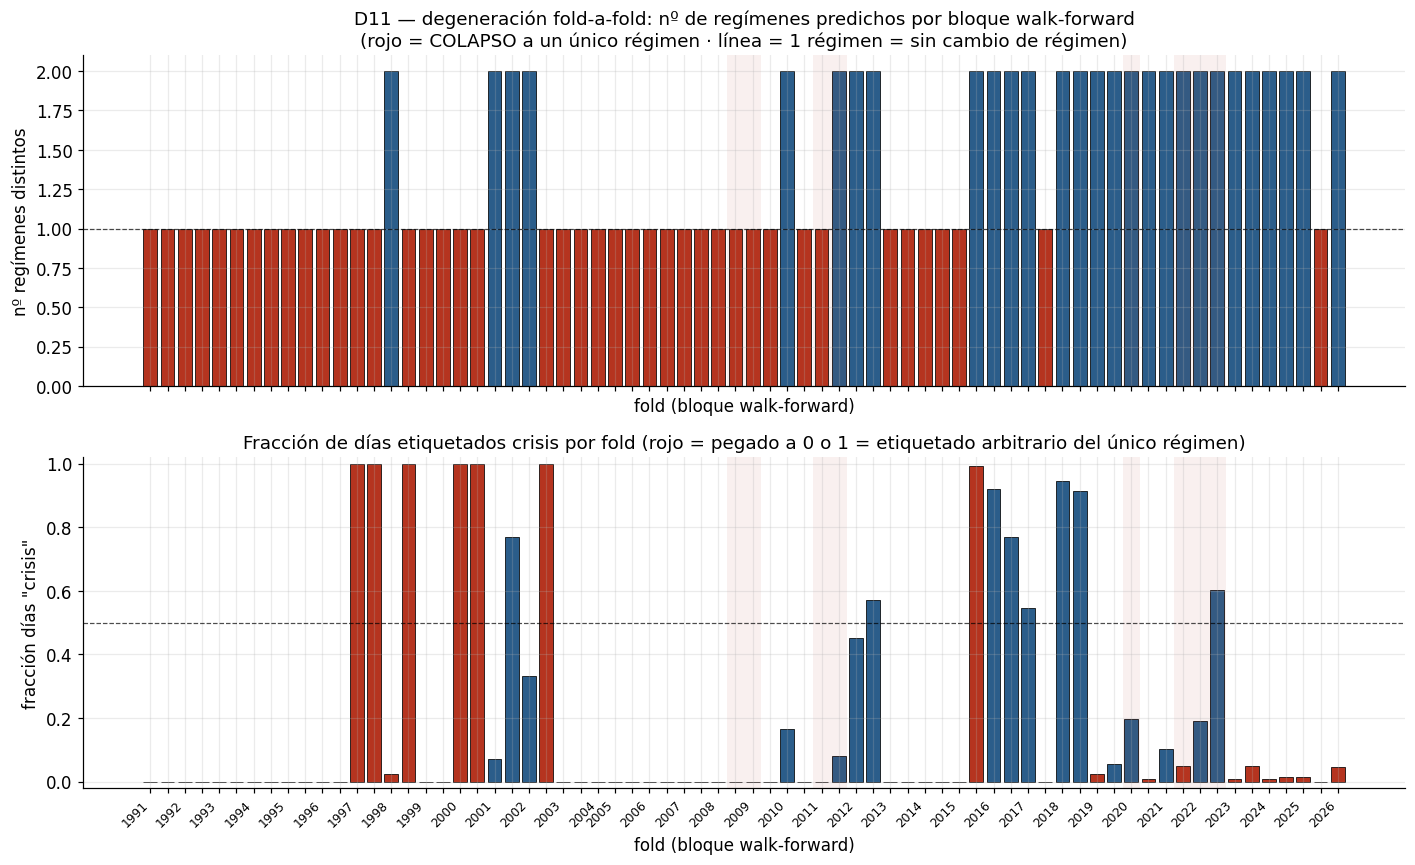

In [8]:
# Reconstrucción fold-a-fold a partir del panel walk-forward (SIN recomputar el ML).
# panel ya trae 'fold' (id de ventana), 'state' canónico (0=calma,1=crisis) y 'p_crisis'.
g = panel.groupby('fold')
fold_ids = list(g.groups.keys())
n_reg   = g['state'].nunique().reindex(fold_ids).to_numpy(dtype=float)             # 1 = colapso
frac_cri = g['state'].apply(lambda s: float((s == 1).mean())).reindex(fold_ids).to_numpy()
p_mean  = g['p_crisis'].mean().reindex(fold_ids).to_numpy()
p_std   = g['p_crisis'].std(ddof=0).reindex(fold_ids).to_numpy()                   # dispersión intra-fold
f_start = g.apply(lambda d: d.index.min()).reindex(fold_ids)
f_end   = g.apply(lambda d: d.index.max()).reindex(fold_ids)

def _overlaps(a, b, windows):
    # ¿El intervalo [a,b] del fold solapa alguna ventana [wa,wb]?
    for wa, wb in windows.values():
        if a <= pd.Timestamp(wb) and b >= pd.Timestamp(wa):
            return True
    return False
ov_crisis = np.array([_overlaps(f_start[i], f_end[i], ev.CRISIS_WINDOWS) for i in fold_ids])
ov_trap   = np.array([_overlaps(f_start[i], f_end[i], ev.FALSE_POSITIVE_WINDOWS) for i in fold_ids])

# Etiquetas de eje x legibles aunque haya decenas de folds: el año al inicio de cada grupo.
years = [f_start[i].year for i in fold_ids]
xlabels = [str(years[k]) if (k == 0 or years[k] != years[k-1]) else '' for k in range(len(fold_ids))]

collapsed = n_reg <= 1
extreme   = (frac_cri >= 0.95) | (frac_cri <= 0.05)
print(f'folds totales = {len(fold_ids)} | colapsados a 1 régimen = {int(collapsed.sum())} '
      f'({collapsed.mean():.0%}) | con etiquetado en esquina (<=5% o >=95%) = {int(extreme.sum())}')
print(f'folds que solapan crisis CONOCIDAS = {int(ov_crisis.sum())}; de ellos colapsados = '
      f'{int((collapsed & ov_crisis).sum())}')

fig, (axa, axb) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
viz.plot_fold_panel(xlabels, n_reg, ylabel='nº regímenes distintos', ref_line=1,
                    highlight=collapsed, ax=axa, baseline_ok=True,
                    title='D11 — degeneración fold-a-fold: nº de regímenes predichos por bloque walk-forward\n'
                          '(rojo = COLAPSO a un único régimen · línea = 1 régimen = sin cambio de régimen)')
viz.plot_fold_panel(xlabels, frac_cri, ylabel='fracción días "crisis"', ref_line=0.5,
                    highlight=extreme, ax=axb, baseline_ok=True,
                    title='Fracción de días etiquetados crisis por fold '
                          '(rojo = pegado a 0 o 1 = etiquetado arbitrario del único régimen)')
axb.set_ylim(-0.02, 1.02)
# Sombra roja tenue en los folds que solapan crisis conocidas (referencia de cobertura).
for k, ov in enumerate(ov_crisis):
    if ov:
        axa.axvspan(k - 0.5, k + 0.5, color='#b5341f', alpha=0.07, lw=0)
        axb.axvspan(k - 0.5, k + 0.5, color='#b5341f', alpha=0.07, lw=0)
fig.tight_layout()
fig.savefig(RESULTS / 'd11_fold_degeneration.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec8"></a>
## 8. Diagnóstico de CAUSA RAÍZ: por qué degenera

La §7 muestra *que* colapsa; esta sección muestra *por qué*, con dos vistas
complementarias y, de nuevo, **sin recomputar el modelo** (solo el panel ya calculado).

**Mecanismo (el relato honesto).** El MS-GARCH-t tiene **10 parámetros** y su ML es
**no convexa**. Al estimarlo en una ventana **rolling de solo 6 años** con `n_init=1`
y `maxiter=100` (concesiones obligadas por el coste del filtro de Hamilton en Python
puro), el optimizador converge a un óptimo donde **los dos regímenes son casi idénticos**:
el posterior filtrado $P(s_t{=}\text{crisis}\mid y_{\le t})$ apenas se mueve dentro del
bloque (panel **a**, dispersión intra-fold ≈ 0 → el filtro **no conmuta**). Con un único
régimen efectivo, la **canonicalización económica por fold** (que reordena 0=calma /
1=crisis con los retornos del *train*) tiene que asignar ese régimen a *algo*; el signo
de esa asignación es **frágil** y bascula de un fold a otro. Resultado (panel **b**):
cada fold cae en una **esquina** del plano (P(crisis) media, fracción crisis) — esquina
(1,1) = "todo crisis" (sube la **tasa de falsas alarmas**), esquina (0,0) = "todo calma".
Cuando el fold que cubre la **GFC** cae en la esquina (0,0), la **cobertura de la GFC se
va a 0 %** aunque globalmente el detector grite "crisis" casi siempre. Esa es,
exactamente, la paradoja `cov_GFC≈0 %` con `far≈0.95`.

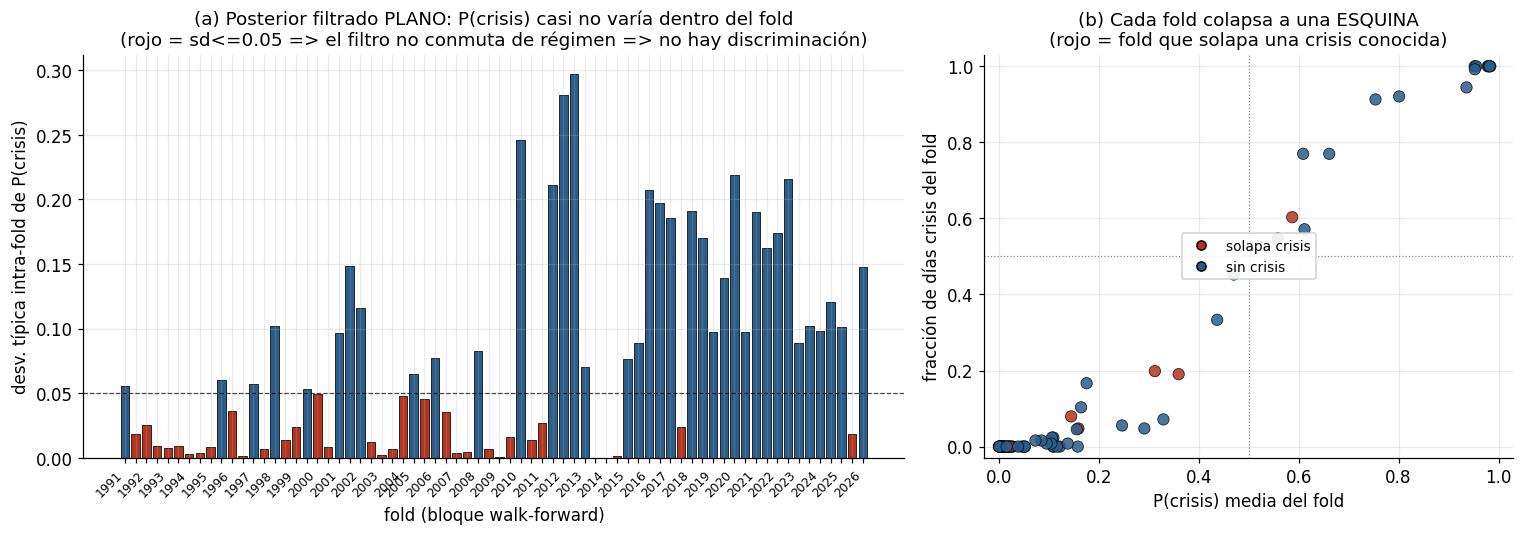

Folds que cubren la GFC (2008-09 -> 2009-03):
  fold 34 [2008-07-22..2009-01-20]: nreg=1  frac_crisis=0.00  P(crisis)_media=0.01  sd=0.007
  fold 35 [2009-01-21..2009-07-21]: nreg=1  frac_crisis=0.00  P(crisis)_media=0.00  sd=0.001
Si frac_crisis~0 en el fold de la GFC => cobertura GFC ~0% AUNQUE el resto colapse a "crisis" (far alto).


In [9]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.55, 1]})

# (a) Dispersión intra-fold del posterior: ~0 => el filtro de Hamilton nunca conmuta.
flat = p_std <= 0.05
viz.plot_fold_panel(xlabels, p_std, ylabel='desv. típica intra-fold de P(crisis)',
                    ref_line=0.05, highlight=flat, ax=axl, baseline_ok=True,
                    title='(a) Posterior filtrado PLANO: P(crisis) casi no varía dentro del fold\n'
                          '(rojo = sd<=0.05 => el filtro no conmuta de régimen => no hay discriminación)')

# (b) Etiquetado arbitrario: cada fold colapsa a una esquina (0,0) o (1,1).
cols = np.where(ov_crisis, '#b5341f', '#2b5d8a')
axr.scatter(p_mean, frac_cri, c=cols, s=55, edgecolors='black', linewidths=0.5, alpha=0.85, zorder=3)
axr.axhline(0.5, color='grey', ls=':', lw=0.8); axr.axvline(0.5, color='grey', ls=':', lw=0.8)
axr.set_xlabel('P(crisis) media del fold'); axr.set_ylabel('fracción de días crisis del fold')
axr.set_xlim(-0.03, 1.03); axr.set_ylim(-0.03, 1.03)
axr.set_title('(b) Cada fold colapsa a una ESQUINA\n(rojo = fold que solapa una crisis conocida)')
from matplotlib.lines import Line2D
axr.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#b5341f', markeredgecolor='black', label='solapa crisis'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2b5d8a', markeredgecolor='black', label='sin crisis')],
    loc='center', framealpha=0.9)
fig.tight_layout()
fig.savefig(RESULTS / 'd11_root_cause.png', dpi=110, bbox_inches='tight'); plt.show()

# Diagnóstico numérico del mecanismo: ¿qué etiqueta arbitraria recibió el fold de la GFC?
gfc_a, gfc_b = ev.CRISIS_WINDOWS['GFC_2008']
gfc_folds = [i for i in fold_ids if _overlaps(f_start[i], f_end[i], {'g': (gfc_a, gfc_b)})]
print('Folds que cubren la GFC (2008-09 -> 2009-03):')
for i in gfc_folds:
    k = fold_ids.index(i)
    print(f'  fold {i} [{f_start[i].date()}..{f_end[i].date()}]: '
          f'nreg={int(n_reg[k])}  frac_crisis={frac_cri[k]:.2f}  P(crisis)_media={p_mean[k]:.2f}  sd={p_std[k]:.3f}')
print('Si frac_crisis~0 en el fold de la GFC => cobertura GFC ~0% AUNQUE el resto colapse a "crisis" (far alto).')

<a id="sec9"></a>
## 9. Tabla fold a fold sobre las ventanas conocidas

Resumen tabular (figura embebible) de los folds que solapan una crisis o una trampa: el
mismo colapso de §§7–8 leído fila a fila. La columna `frac_crisis` resaltada deja ver de
un vistazo el etiquetado en esquina (≈0 % o ≈100 %).

,periodo,tipo,n_reg,frac_crisis,P(crisis) media
fold,,,,,
34,2008-07-22 -> 2009-01-20,crisis,1,0%,0.01
35,2009-01-21 -> 2009-07-21,crisis,1,0%,0.00
39,2011-01-20 -> 2011-07-20,crisis,1,0%,0.02
40,2011-07-21 -> 2012-01-19,crisis,2,8%,0.14
43,2013-01-23 -> 2013-07-23,trampa,1,0%,0.05
44,2013-07-24 -> 2014-01-22,trampa,1,0%,0.00
54,2018-07-26 -> 2019-01-25,trampa,2,91%,0.75
57,2020-01-28 -> 2020-07-27,crisis,2,20%,0.31
60,2021-07-28 -> 2022-01-25,crisis,2,5%,0.16


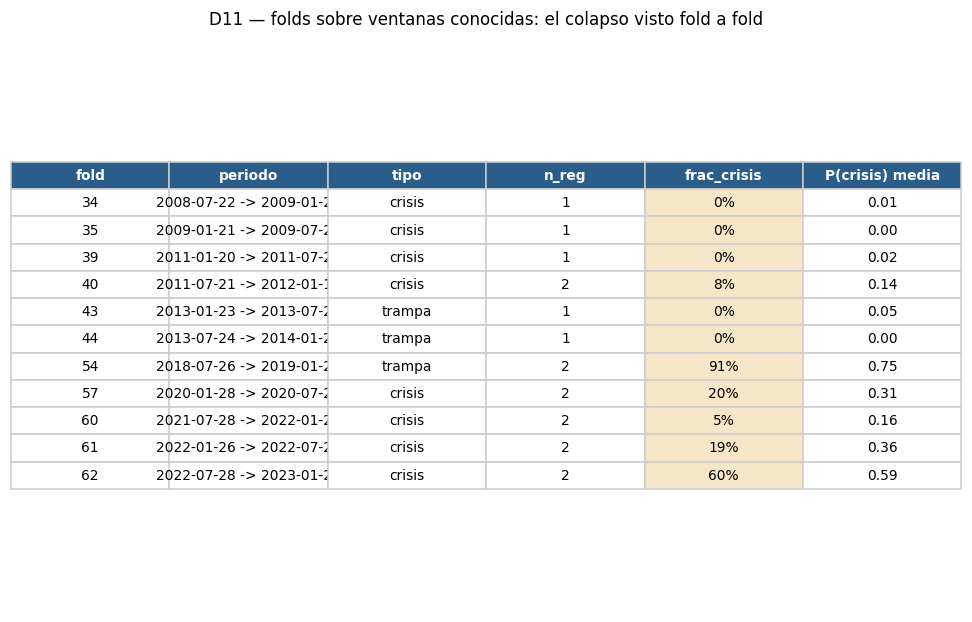

In [10]:
rows = []
for k, i in enumerate(fold_ids):
    if not (ov_crisis[k] or ov_trap[k]):
        continue
    rows.append({'fold': int(i),
                 'periodo': f'{f_start[i].date()} -> {f_end[i].date()}',
                 'tipo': 'crisis' if ov_crisis[k] else 'trampa',
                 'n_reg': int(n_reg[k]),
                 'frac_crisis': frac_cri[k],
                 'P(crisis) media': p_mean[k]})
fold_tbl = pd.DataFrame(rows).set_index('fold')
display(fold_tbl.style.format({'frac_crisis': '{:.0%}', 'P(crisis) media': '{:.2f}'}))
fig = viz.render_table_figure(
    fold_tbl, title='D11 — folds sobre ventanas conocidas: el colapso visto fold a fold',
    highlight_cols=['frac_crisis'],
    fmt={'frac_crisis': '{:.0%}', 'P(crisis) media': '{:.2f}', 'n_reg': '{:.0f}'})
fig.savefig(RESULTS / 'd11_fold_table.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec10"></a>
## 10. Volcado de métricas a results/ (esquema canónico 32 columnas)

In [11]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 32, f'esperaba 32 columnas (esquema canonico), hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_11_msgarch_regime.csv', index=False)
print('Guardado results/metrics_11_msgarch_regime.csv  (1 fila,', tbl.shape[1], 'columnas)')

# NOTA (saneamiento Ola 0): este builder ya NO actualiza metrics_master.csv de forma
# incremental (leer-filtrar-concatenar provocaba condicion de carrera al correr builders
# en paralelo). Cada builder escribe SOLO su metrics_NN_*.csv; el master unificado se
# reconstruye de forma centralizada con:  python scripts/verify/_rebuild_master.py
display(tbl.T)

Guardado results/metrics_11_msgarch_regime.csv  (1 fila, 32 columnas)


,0
detector,msgarch_regime
n_states,2
ventana_eval,1991-03-04→2026-06-12 (n=8782)
oos_start,1991-03-04
oos_end,2026-06-12
n_oos,8782
false_alarm_rate,0.949441
switching_rate,0.0312
mean_regime_duration,31.934545
label_stability,0.889406


<a id="sec11"></a>
## 11. Conclusión D11 (exploratoria) — un negativo capitalizado a favor de la parsimonia

**Decisión:** en vez de declararlo no implementable por falta de librería madura
(MS-GARCH solo está bien en R y aquí `rpy2` no existe), se **implementó desde cero** el
MS-GARCH de **Haas-Mittnik-Paolella (2004)** — la única especificación **tratable** en
Python puro (recursiones GARCH paralelas, **sin path dependence**) — con ML por **filtro
de Hamilton**, causal vía posterior FILTRADO con burn-in.

**Qué aporta sobre D5/D6:** es la síntesis genuina — régimen de Markov latente **Y**
dinámica GARCH-t dentro de cada régimen, con posterior de crisis filtrado y BIC
comparable. No es redundante: D5 no tiene ARCH dentro del régimen y D6 no tiene régimen
latente (umbraliza una sigma).

**Hallazgos in-sample (con los números de arriba):** crisis = régimen de **alta vol
incondicional** (verificado, no invertido); $\nu$ bajo confirma **colas gordas**;
transición muy persistente. *In-sample, el modelo es razonable.* El problema aparece
**out-of-sample**.

**El resultado NEGATIVO (lo importante de D11), hecho evidencia visual (§§7–9):**
out-of-sample el MS-GARCH **degenera**. Reentrenado en ventana rolling de 6 años con
`n_init=1`, **colapsa a un único régimen** en la inmensa mayoría de folds (§7, panel
superior: barras rojas), su posterior filtrado se queda **plano** (§8a, no conmuta) y la
canonicalización económica de ese único régimen se vuelve **arbitraria** fold a fold (§8b,
cada bloque cae a una *esquina* (0,0) o (1,1)). De ahí la patología que ven las métricas
agregadas: **cobertura GFC ≈ 0 %** (el fold de 2008 cayó a la esquina "todo calma") con
**`far` ≈ 0.95** (el resto colapsa a "todo crisis"). No es un bug de implementación —la
causalidad y el etiquetado están verificados (§§1–2)— sino una **infra-identificación
estadística**: 10 parámetros no convexos sobre ventanas cortas no se pueden estimar de
forma estable, y el walk-forward honesto lo destapa donde el ajuste in-sample lo ocultaba.

**Hipótesis CP2 → veredicto.** *Hipótesis:* "añadir dinámica GARCH **dentro** de cada
régimen de Markov (vs D5, sin ARCH) debería mejorar la detección de crisis."
*Veredicto:* **RECHAZADA out-of-sample.** La expresividad extra no se traduce en señal
porque el modelo no es **estimable de forma estable** en el régimen walk-forward de coste
acotado; los detectores **más parsimoniosos ganan**: **D8** (HMM-t, régimen sin ARCH
explícito pero estimable) y **D6** (GARCH-t de **un** régimen, sin estado latente)
producen cobertura/`far` muy superiores. D11 es, por tanto, un **argumento empírico a
favor de la parsimonia**: más parámetros ⇒ más varianza de estimación ⇒ peor
generalización, justamente lo que el marco causal está diseñado para revelar.

**Límites (honestos):** (1) es la variante **paralela path-independiente**, no el
MS-GARCH path-dependiente "completo" ni el colapso de Gray (1996), ni las familias extra
del paquete `MSGARCH` de R; (2) ML **no convexo** → sensible a óptimos locales
(mitigado con multistart y con la canonicalización vol-primaria del núcleo que neutraliza
el *label switching* in-sample, pero **insuficiente** out-of-sample, como muestra §7);
(3) **coste** alto → re-estimación **semestral** en ventana rolling (no diaria), aunque el
posterior filtrado intra-bloque sí es diario. **No se descarta** que un MS-GARCH *podría*
funcionar con `rpy2`+`MSGARCH` de R, multistart agresivo y ventanas más largas; lo que D11
documenta es que **en este stack y bajo coste acotado, no es competitivo**.

**Cierre.** Como detector EXPLORATORIO, D11 cumple su papel doble: (i) demuestra que el
MS-GARCH **es** abordable en Python puro sin R, y (ii) —más valioso para el TFM— aporta un
**negativo limpio y bien diagnosticado** que refuerza la elección de modelos simples. Un
negativo que se entiende vale más que un positivo que no se explica.